In [1]:
#import jax
#import jax.numpy as jnp
from sklearn.preprocessing import normalize
import math
import matplotlib.pyplot as plt
import numpy as np
import random
from itertools import compress
np.random.seed()

# Check dependance of m on beta

## Data and weight sampling

In [2]:
def create_data(n,d):
    """
    INPUT: 1)n: number of input vector and output values to sample
           2)d: dimension of input vectors
    OUTPUT: Returns n random vectors of dimension d ~N(0,1_d), normalised to the unit sphere, and n random numbers ~ N(0,1)
    OUTPUT SHAPE: ([[x1],...,[xn]],[y1,...,yn])
    """

    X = normalize(np.random.normal(size=(n,d)), axis=1, norm='l2')
    Y = np.random.normal(size=n)
    return(X,Y)

In [3]:
def create_weights(m,d):
    """
    INPUT: m,d real numbers
    OUTPUT: W a matrix of size d*m with iid ~N(0,1) entries, a a vector of length m with entries ~ Rademacher
    OUTPUT SHAPE: ([a1,...,am],[[w1],...,[wm]])
    """
    a = np.random.choice(np.array([int(-1),int(1)]),size = m)
    W = np.random.normal(size=(m,d))
    return(a,W)
    

## Auxiliary function

In [4]:
def m_beta(beta,n,delta,C_m):
    """
    INPUT: 1)beta: parameter of the approximate heaviside
           2)n: number of input data
           3)delta: desired degree of certainty 
           4)C_m: constant estimated by user
    OUTPUT: Required value of m for main theorem to hold with porbability at least 1-delta
    """
    return(((C_m*n**5)/(delta**2 * beta**2))*math.log((n)/(delta)))

## Plot dependency of m on other parameters

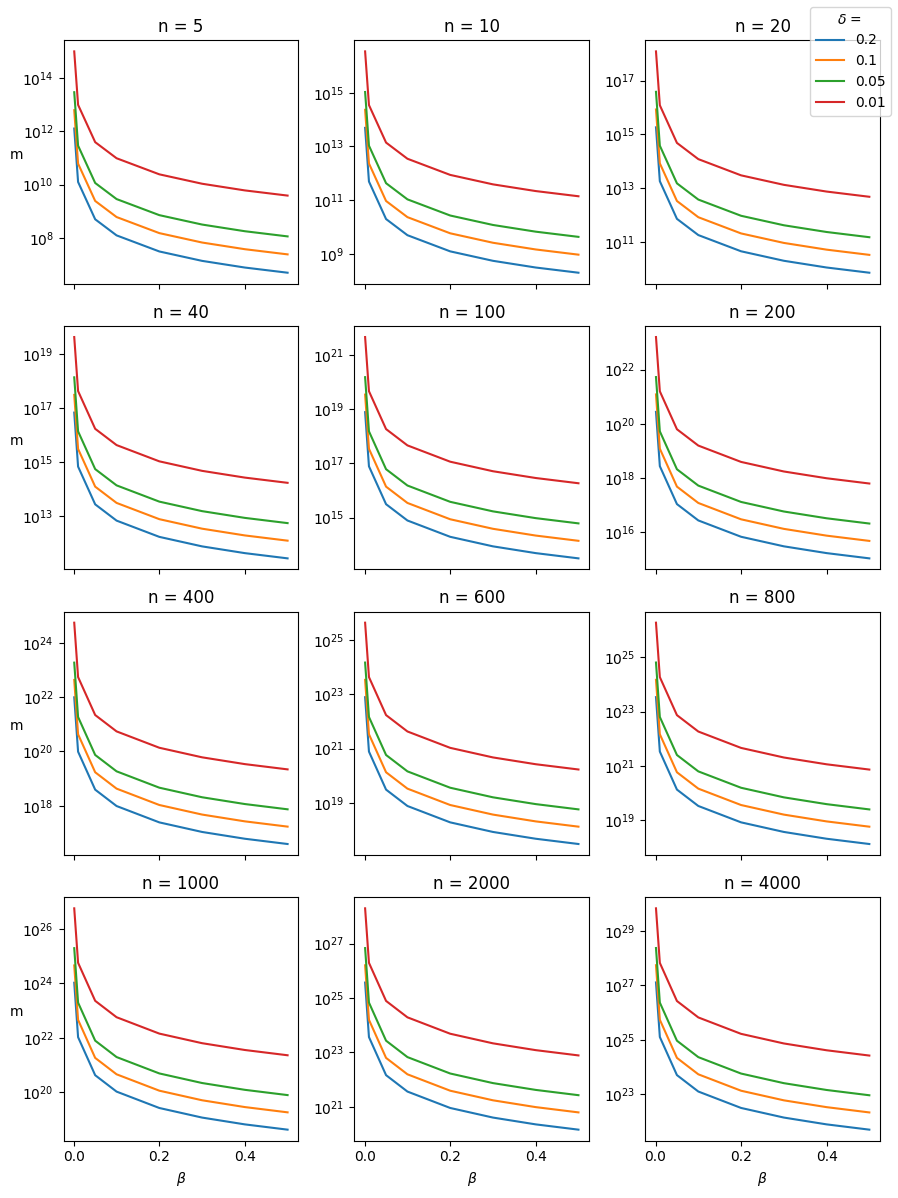

In [5]:
#--------------Show dependency of m on b, delta and n--------------

betas = [0.5,0.4,0.3,0.2,0.1,0.05,0.01,0.001]                   #values of beta to compute m for
deltas = [0.2,0.1,0.05,0.01]                                    #values of delta to compute m for
ns = [5,10,20,40,100,200,400,600,800,1000,2000,4000]            #values of n to compute m for
C_m = 5                                                         #estimated constant
nrows = math.ceil(math.sqrt(len(ns)))                           #we need as many subplots as values for n, choose the number 
ncols = math.ceil(len(ns)/nrows)                                #of rows and columns automatically
fig, axs = plt.subplots(nrows,ncols,figsize=(ncols*3,nrows*3),squeeze=False,sharex=True)    #squeeze = False as otherwhise axs cannot always be accessed using two indices
for i in range(len(ns)):                                                            #(for example when there is only one row, only one index is expected if squeeze = True)
    n = ns[i]
    for delta in deltas:
        axs[i//ncols,i%ncols].plot(betas,[m_beta(beta,n,delta,C_m) for beta in betas])      #for each delta, plot the required value of m versus b for given n
    axs[i//ncols,i%ncols].set_yscale("log")                     #log scale for better legibility
    axs[i//ncols,i%ncols].set_title("n = " + str(n))            #subtitle contains value of n
for i in range(nrows):
    axs[i,0].set_ylabel("m",rotation=0)            #rotate y ticks for legibility
for j in range(ncols):
    axs[-1,j].set_xlabel("$\\beta$")                            #only need to label x axes on the last row
fig.legend(deltas,title="$\\delta$ = ")                         #add title to legend for clarity
plt.tight_layout()                                              #ensure nicer spacing
plt.show()

#----------------------------

# 1) Show evolution of weights, and check influence of inner and outer weights

## Auxiliary functions

In [5]:
#--------------Surrogate heaviside--------------

def sigma_beta(x,b):
    """
    INPUT: 1)x: value in R
           2)b: beta, the parameter for the surrogate heaviside function
    OUTPUT: Value of the surrogate gradient with parameter beta at x
    """
    if abs(x) <= b:
        return 1/(2*b)
    else:
        return 0
    
#----------------------------

#--------------Loss function--------------
    
def compute_loss(X,y):
    """
    INPUT: 1)X: Vector of dimension n containing the outputs of the neural network
           2)y: Vector of dimension n containing the desired output
    OUTPUT: Squared loss
    """
    res = 0
    for i in range(len(X)):
        res += (X[i]-y[i])**2
    return(0.5*math.sqrt(res))

#----------------------------

#--------------Compute output using real heaviside--------------

def NTK_output(a,W,X):
    """
    INPUT: 1)a: outer weights
           2)W: inner weights
           3)X: input data
    OUTPUT: Output of shallow heaviside neural network, for each input data
    """
    f = []
    for j in range(len(X)):
        res = 0
        for r in range(len(W)):
            if np.dot(W[r],X[j]) >= 0:
                res += a[r]
        f += [res/(math.sqrt(len(W)))]
    return(f)

#----------------------------

#--------------Compute output using approximate heaviside--------------

def NTK_output_beta(a,W,X,b):
    """
    INPUT: 1)a: outer weights
           2)W: inner weights
           3)X: input data
           4)b: parameter for surrogate activation function
    OUTPUT: Output of shallow approximate heaviside neural network, for each input data
    """
    f = []
    for j in range(len(X)):
        res = 0
        for r in range(len(W)):
            x = np.dot(W[r],X[j])
            if abs(x) <= b:
                res += a[r]*((1/2) + (x/(2*b)))
            elif x > b:
                res += a[r]
        f += [res/(math.sqrt(len(W)))]
    return(f)

#----------------------------

## Shallow NTK network class

In [ ]:
class NTK_shallow:
    
    #--------------Initialisation--------------

    def __init__(self,n,d,m,b,train_a,X=[],y=[],a=[],W=[]):
        #store given variables
        self.n = n                  #number of input vectors
        self.d = d                  #dimension of input vectors
        self.m = m                  #number of neurons
        self.b = b                  #parameter for surrogate heaviside
        self.train_a = train_a      #if true, the outer weights are trained

        #generate random data if required and store it
        if len(X) == 0:
            if len(y) == 0:
                self.X,self.y = create_data(self.n,self.d)
            else:
                self.X = create_data(self.n,self.d)[0]
                self.y = np.copy(y)
        else:
            if len(y) == 0:
                self.y = create_data(self.n,self.d)[1]
                self.X = np.copy(X)
            else:
                self.X = np.copy(X)
                self.y = np.copy(y)

        #initialise weights of the network if required and store them
        if len(a) == 0:
            if len(W) == 0:
                self.a, self.W = create_weights(self.m,self.d)
            else:
                self.a = create_weights(self.m,self.d)[0]
                self.W = np.copy(W)
        else:
            if len(W) == 0:
                self.W = create_weights(self.m,self.d)[1]
                self.a = np.copy(a)
            else:
                self.W = np.copy(W)
                self.a = np.copy(a)

        #compute current value of f and store it
        self.f = NTK_output(self.a,self.W,self.X)
        self.f_iters = [self.f]
        self.f_beta_iters = [NTK_output_beta(self.a,self.W,self.X,self.b)]

        #create object to store generated frames
        self.W_iters = [np.copy(self.W)]

        #compute initial loss and store it
        self.losses = [compute_loss(self.f,self.y)]

        #store outer weights
        self.a_iters = [np.copy(self.a)]

        #We want to study if the outer weights or inner weights contribute more to lowering the loss at early vs late stages of training
        self.loss_diffs = []

        #We want to study how a_r*(<w_r,X>) evolves over time
        self.awx_iter = [[self.a[r]*np.dot(self.W[r],self.X[0]) for r in range(self.m)]]

    #----------------------------

    #--------------Gradient wrt inner weights--------------
        
    def grad_w(self,r):
        """
        INPUT: r: index of inner weight to compute gradient for
        OUTPUT: gradient wrt w_r
        """
        
        res = np.asarray([0 for x in range(self.d)])        #gradient is a d dimensional vector, we initialise it at 0 and for each iteration perform an addition
        for j in range(self.n):                             #iterate over input data
            mult_fact = (self.f[j] - self.y[j]) * self.a[r] * sigma_beta(np.dot(self.W[r],self.X[j]),self.b)    #compute scalar part of summand
            res = res + mult_fact * self.X[j]               #multiply by corresponding input vector and add to the result vector
        return(res/(math.sqrt(self.m)))                     #normalize by sqrt(m) and return
    
    #----------------------------

    #--------------Gradient wrt outer weights--------------
    
    def grad_a(self,r):
        """
        INPUT: r: index of outer weight to compute gradient for
        OUTPUT: gradient wrt a_r
        """
        res = 0                                             #value to store output
        for j in range(self.n):                             #iterate over input data
            if np.dot(self.W[r],self.X[j]) >= 0:            #compute summand
                res += (self.f[j] - self.y[j])
        return(res/(math.sqrt(self.m)))                     #return res normalised by sqrt(m)
    
    #----------------------------

    #--------------Update weights of the network--------------

    def update_weights(self,t):
        """
        INPUT: t: size of step in time per iteration
        OUTPUT: No output, updates the weights by substracting t times the corresponding gradient
        Also updates the value of f, store the loss in self.losses, and if the outer weights are trained, stores the loss difference generated
        by the inner and outer weights respectively
        """
        if self.train_a:
            prev_W = np.copy(self.W)                            #store previous weights to be able to compute what effect
            prev_a = np.copy(self.a)                            #they had on the loss over one iteration
            self.a = np.copy([self.a[r]-self.grad_a(r)*t for r in range(self.m)])   #update outer weights, copy as a is a reference type variable
        
        for r in range(self.m):
            self.W[r] = np.copy(self.W[r] - self.grad_w(r)*t)   #update inner weights, copy as W is a reference type variable
        

        self.W_iters.append(np.copy(self.W))                    #store evolution of inner weights
        self.a_iters.append(np.copy(self.a))                    #store evolution of outer weights
        self.f = NTK_output(self.a,self.W,self.X)               #update value of f
        self.f_iters.append(self.f)
        self.f_beta_iters.append(NTK_output_beta(self.a,self.W,self.X,self.b))
        self.losses.append(compute_loss(self.f,self.y))         #compute current loss and store it
        self.awx_iter.append([self.a[r]*np.dot(self.W[r],self.X[0]) for r in range(self.m)])
        if self.train_a:                                        #compute loss difference generated by w and a respectively and store it
            self.loss_diffs.append([compute_loss(NTK_output(self.a,prev_W,self.X),self.y)-self.losses[-2],compute_loss(NTK_output(prev_a,self.W,self.X),self.y)-self.losses[-2]])

    #----------------------------

    #--------------Simulate num steps of lenght t--------------

    def run_sim(self,t,num):
        """
        INPUT: 1)t: size of time step per iteration
               2)num: number of steps for the simulation
        OUTPUT: No output, runs the simulation of the given parameters 
        """
        for i in range(num):
            self.update_weights(t)
            
    #----------------------------


## Plotting functions

In [7]:
#--------------Nice plotting of vector--------------

def plot_vector(x,y,color="black"):
    """
    INPUT: coordinates x and y of a two dimension vector and a desired colour
    OUTPUT: no output, plots vector with a small arrow at the end in the chosen colour
    """
    plt.plot([0,x],[0,y],color = color)
    plt.plot([0.95*x+0.05*y,x],[0.95*y-0.05*x,y],color = color)
    plt.plot([0.95*x-0.05*y,x],[0.95*y+0.05*x,y],color = color)

#----------------------------

#--------------Plotting of inner weight over time--------------

def plot_weight(NTK_inst,r):
    """
    INPUT: 1)NTK_inst: shallow network instance
           2)r: index of inner weight to plot
    OUTPUT: no output, plots evolution of the chosen weight over the already run simulation
    IMPORTANT: d is supposed to be 2
    """
    W_x = [x[r][0] for x in NTK_inst.W_iters]
    W_y = [x[r][1] for x in NTK_inst.W_iters]
    plt.plot(W_x,W_y)    

#----------------------------

#--------------Plotting evolution of network--------------    

def train_plot(n,d,m,b,t,num,train_a = True):
    """
    INPUT: 1)n: number of input data for network
           2)d: dimension of input data
           3)m: number of neurons
           4)t: time step for simulation
           5)num: number of steps for simulation
           6)train_a: indicates whether or not to train outer weights
    OUTPUT: No output. Trains a shallow network with the given parameters, and runs the desired simulation. Once done, yields a plot containing:
           1)If the dimension is = 2: evolution of inner weights in R^2
           2)If the inner weights are trained: plot with 3 subplots:
                a)Evolution of total loss over time
                b)Evolution of cumulated loss difference for inner and outer weights over time
                c)Step by step loss difference for inner and outer weights over time
           3)If the inner weights are not trained: plot with loss over time
    """

    #-------Create and train shallow network-------

    NTK_inst = NTK_shallow(n,d,m,b,train_a)
    NTK_inst.run_sim(t,num)

    #--------------

    #-------Plotting inner weights evolution-------
    
    if d == 2:
        for i in range(NTK_inst.n):     #plot input vectors
            plot_vector(NTK_inst.X[i][0],NTK_inst.X[i][1])
        for r in range(NTK_inst.m):     #plot evolution of weights
            plot_weight(NTK_inst,r)

        ax = plt.gca()                  #ensuring axes have the same scale
        ax.set_aspect('equal')
        plt.show()

    #--------------

    #-------Plotting loss-------
    
    if not train_a:
        plt.plot([i for i in range(len(NTK_inst.losses))],NTK_inst.losses)      
        plt.xlabel("Iteration")
        plt.ylabel("Loss")
        plt.show()

    #--------------

    #-------Plotting total loss and loss wrt to inner/outer weights-------

    if train_a:
        fig, ax = plt.subplots(1,3,figsize=(13,4))

        loss_diffs_a = [x[0] for x in NTK_inst.loss_diffs]      #step by step difference in loss due to outer weights
        loss_diffs_W = [x[1] for x in NTK_inst.loss_diffs]      #step by step difference in loss due to inner weights

        #Plot loss over time
        ax[0].plot([i*t for i in range(len(NTK_inst.losses))],NTK_inst.losses)
        ax[0].set_xlabel("Time")
        ax[0].set_ylabel("Loss")

        #Plot cumulated loss difference wrt inner and outer weights
        ax[1].plot([i*t for i in range(len(NTK_inst.loss_diffs))],np.cumsum(loss_diffs_a),label="Outer weights")
        ax[1].plot([i*t for i in range(len(NTK_inst.loss_diffs))],np.cumsum(loss_diffs_W),label="Inner weights")
        ax[1].set_xlabel("Time")
        ax[1].set_ylabel("Cumulated loss difference")

        #Plot step by step difference in loss wrt to inner and outer weights
        ax[2].plot([i*t for i in range(len(NTK_inst.loss_diffs))],loss_diffs_a,label="Outer weights")
        ax[2].plot([i*t for i in range(len(NTK_inst.loss_diffs))],loss_diffs_W,label="Inner weights")
        ax[2].legend()                                          #legend is only needed once as it is the same for each subplot
        ax[2].set_xlabel("Time")
        ax[2].set_ylabel("Loss difference")

        fig.suptitle("n = " + str(n) + " | " + "d = " + str(d) + " | " + "m = " + str(m) + " | " + "$\\beta$" + " = " + str(b))
        plt.tight_layout()                                      #ensure that everything is nicely spaced
        plt.show()

        #--------------

#----------------------------


## Running examples

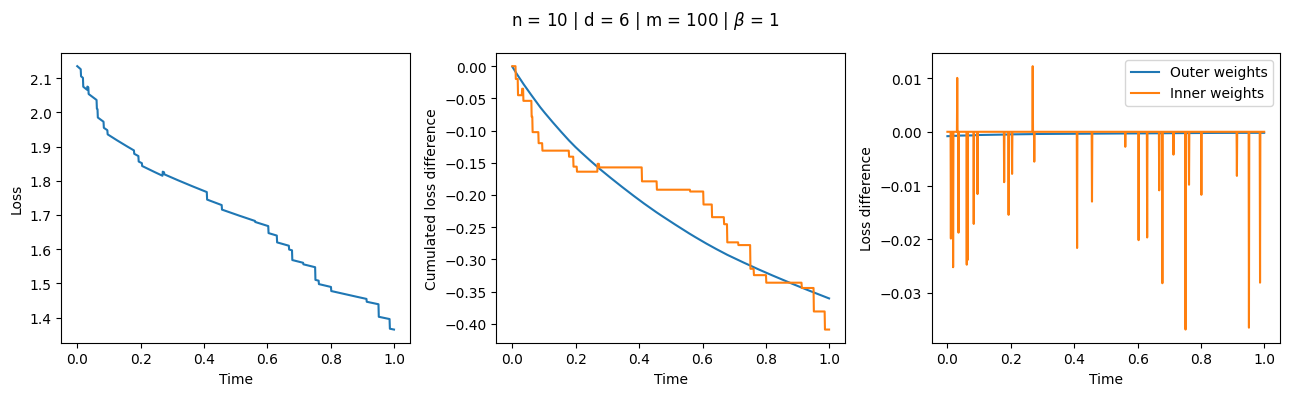

In [88]:
train_plot(n=10,d=6,m=100,b=1,t=0.001,num=1000,train_a=True)

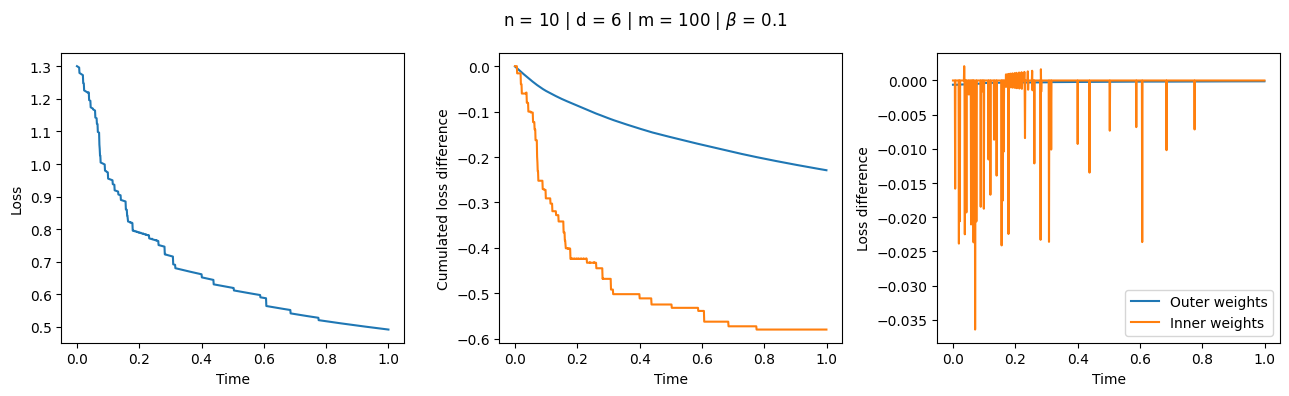

In [60]:
train_plot(n=10,d=6,m=100,b=0.1,t=0.001,num=1000,train_a=True)

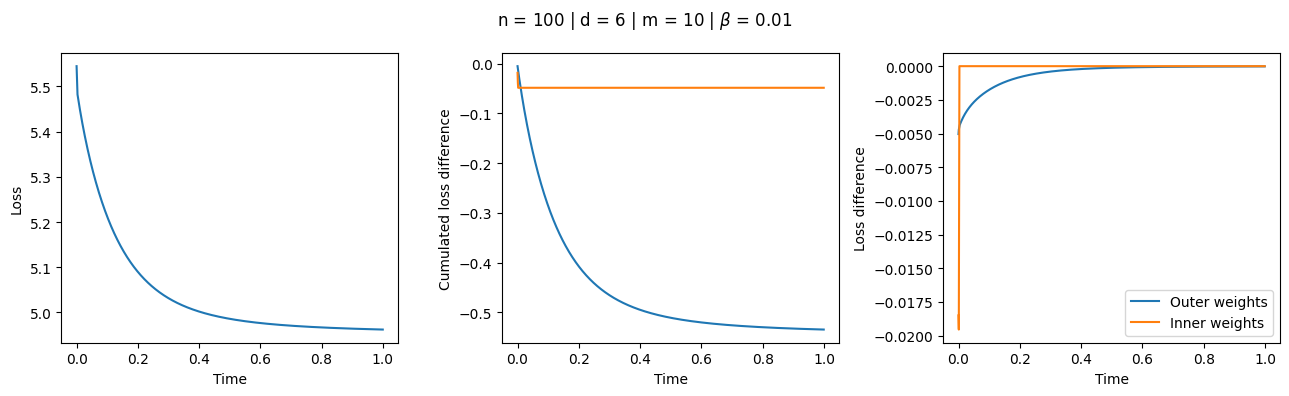

In [61]:
train_plot(n=100,d=6,m=10,b=0.01,t=0.001,num=1000,train_a=True)

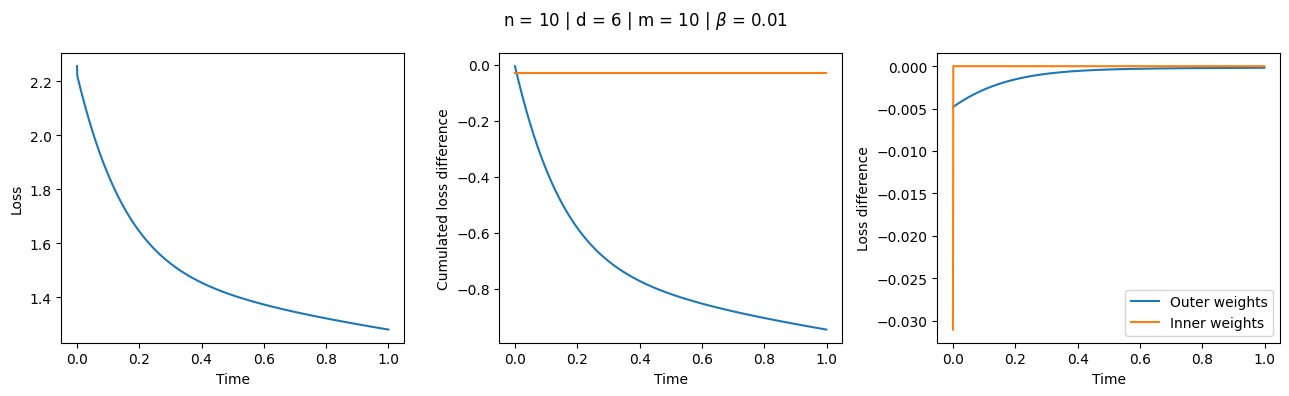

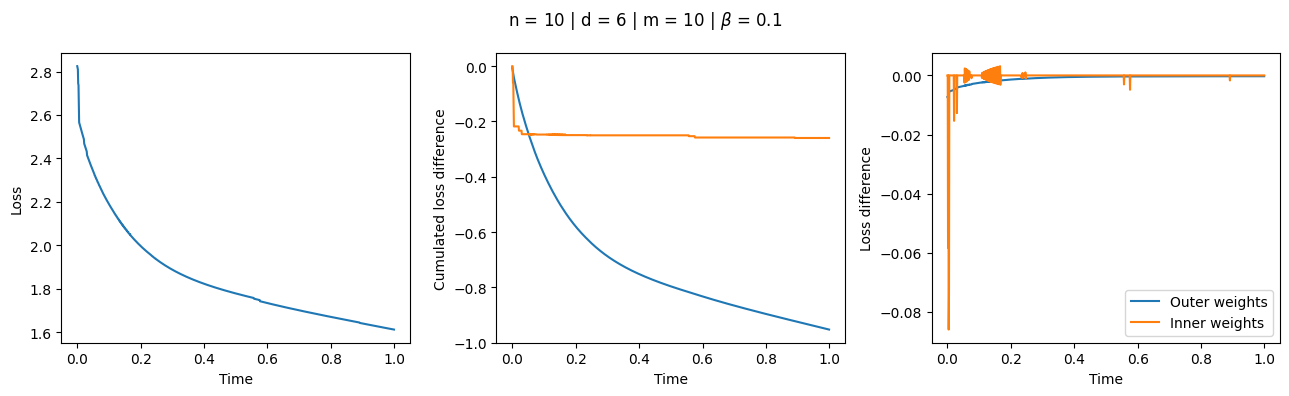

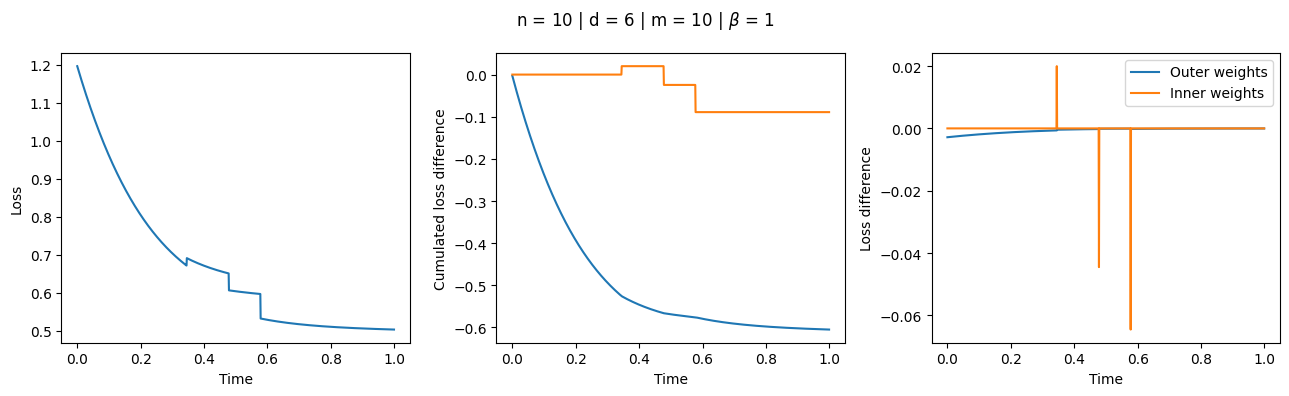

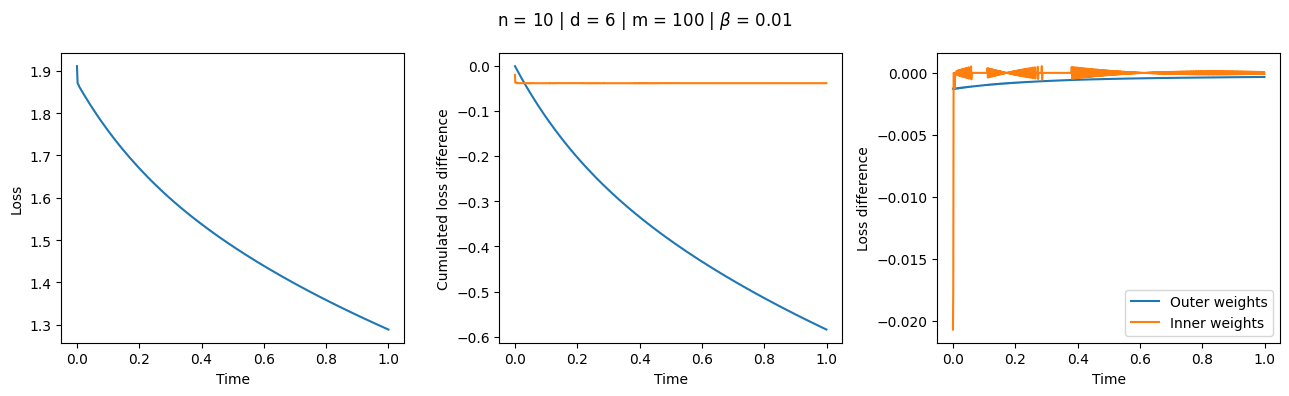

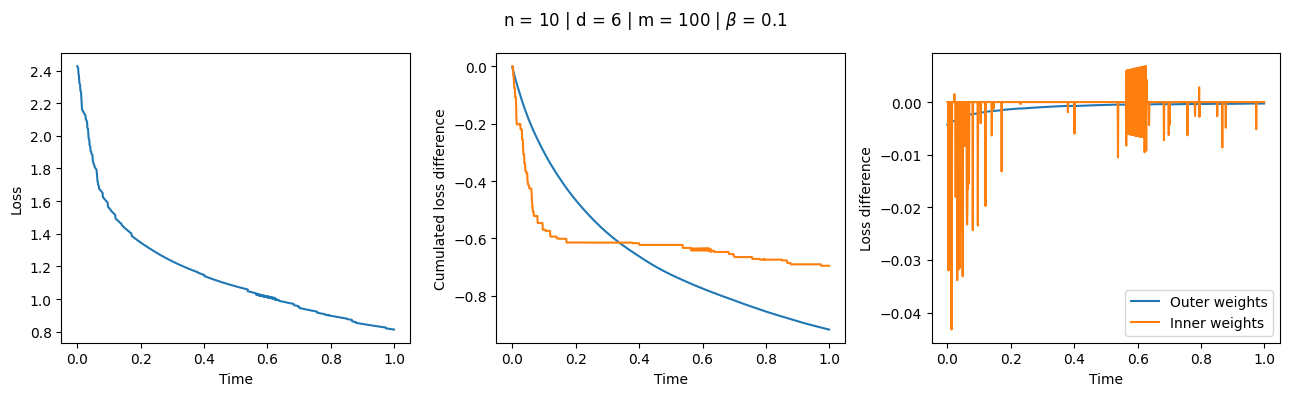

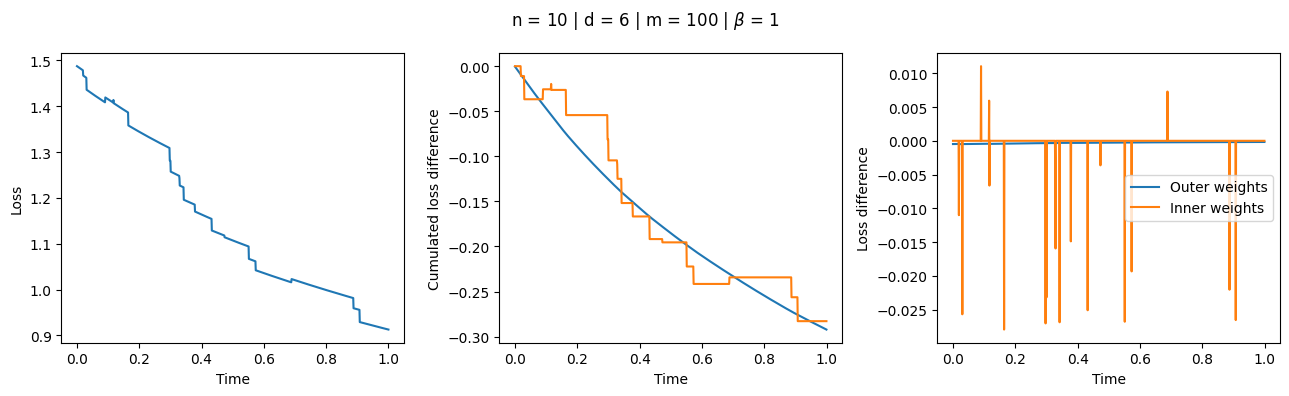

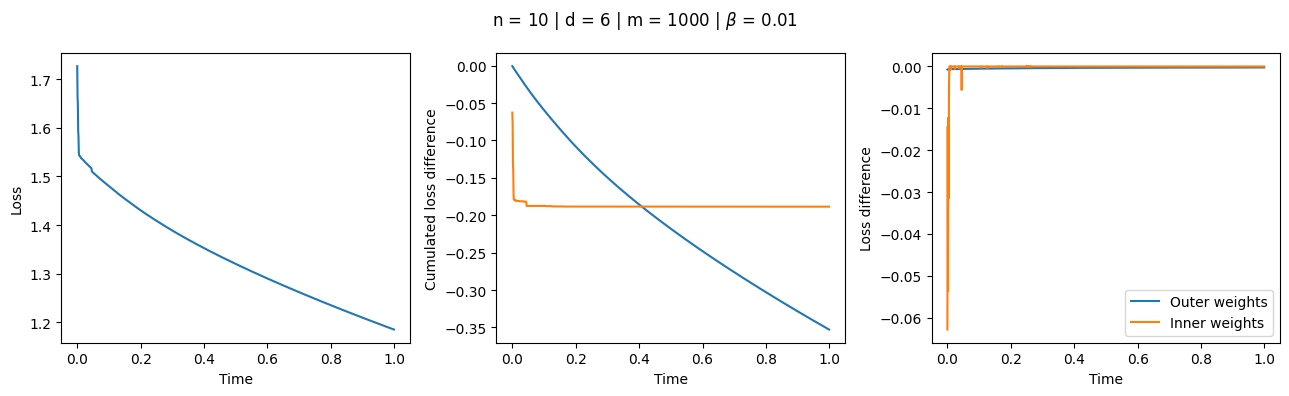

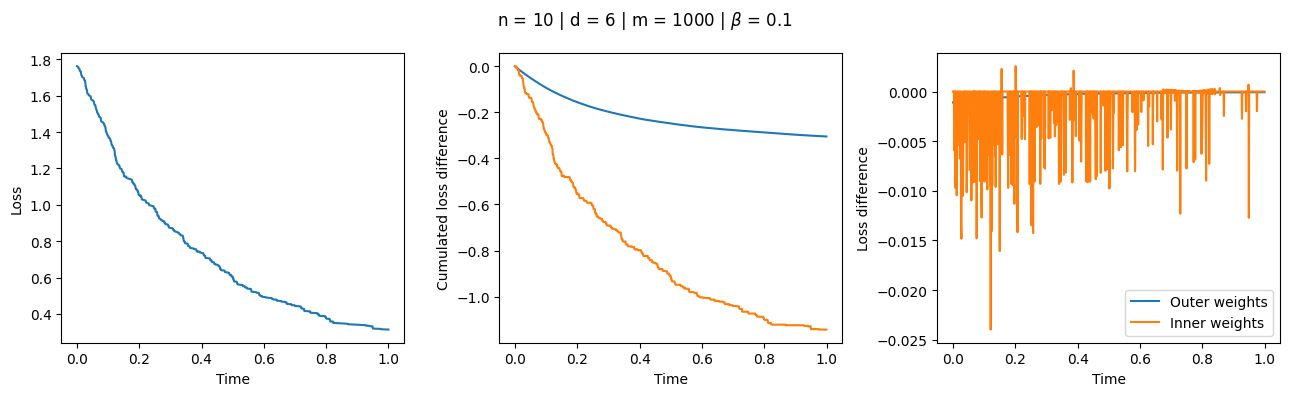

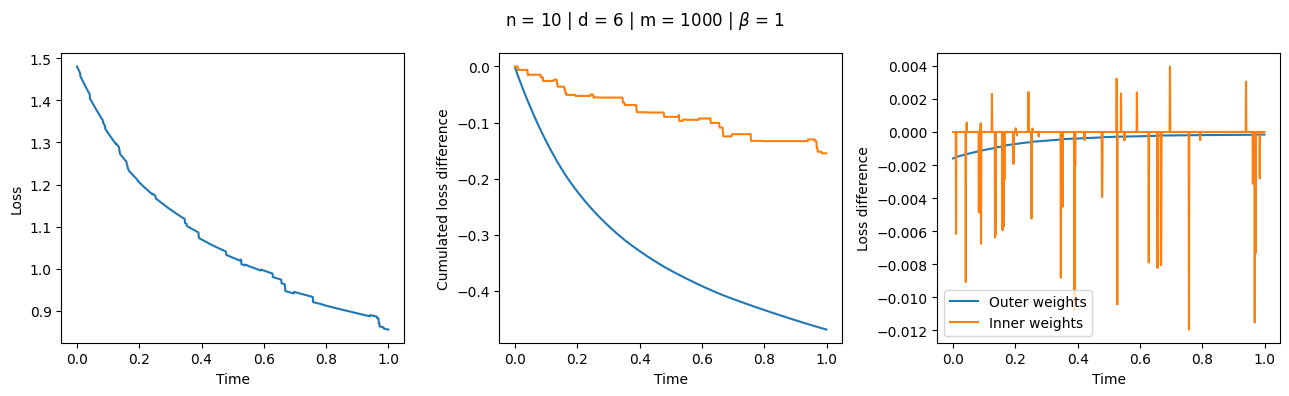

In [62]:
for m in [10,100,1000]:
    for b in [0.01,0.1,1]:
        train_plot(n=10,d=6,m=m,b=b,t=0.001,num=1000,train_a=True)

# 2) Check if training the outer weights or not makes a big difference

## Main function

In [8]:
def compare(n,d,m,b,t,num_iter,num_sim):
    """
    INPUT: 1)n: number of input data for network
           2)d: dimension of input data
           3)m: number of neurons
           4)t: time step for simulation
           5)num_iter: number of steps for simulation
           6)num_sim: number of simulations to run for each case
    OUTPUT: No output. Plots a grid, where each row shows the loss of num_sim simulations, one row has the outer weights trained, and the other one does not
    """
    fig, axs = plt.subplots(2,num_sim,figsize=(4*num_sim,8),sharex = True, sharey = True)
    for i in range(num_sim):
        NTK_with = NTK_shallow(n,d,m,b,train_a=True)
        NTK_without = NTK_shallow(n,d,m,b,train_a=False)
        NTK_with.run_sim(t,num_iter)
        NTK_without.run_sim(t,num_iter)
        losses_with = NTK_with.losses
        losses_without = NTK_without.losses
        axs[0][i].plot([x for x in range(num_iter+1)],losses_with,label="With outer weights",color="blue")
        axs[1][i].plot([x for x in range(num_iter+1)],losses_without,label="Without outer weights",color="orange")
        if i == 0:
            axs[0][i].set_ylabel("Loss")
            axs[1][i].set_ylabel("Loss")
        axs[1][i].set_xlabel("Iteration")
    axs[0][-1].legend()
    axs[1][-1].legend()
    fig.suptitle("Comparison of loss with and without training the outer weights")
    plt.tight_layout()
    plt.show()

## Running examples

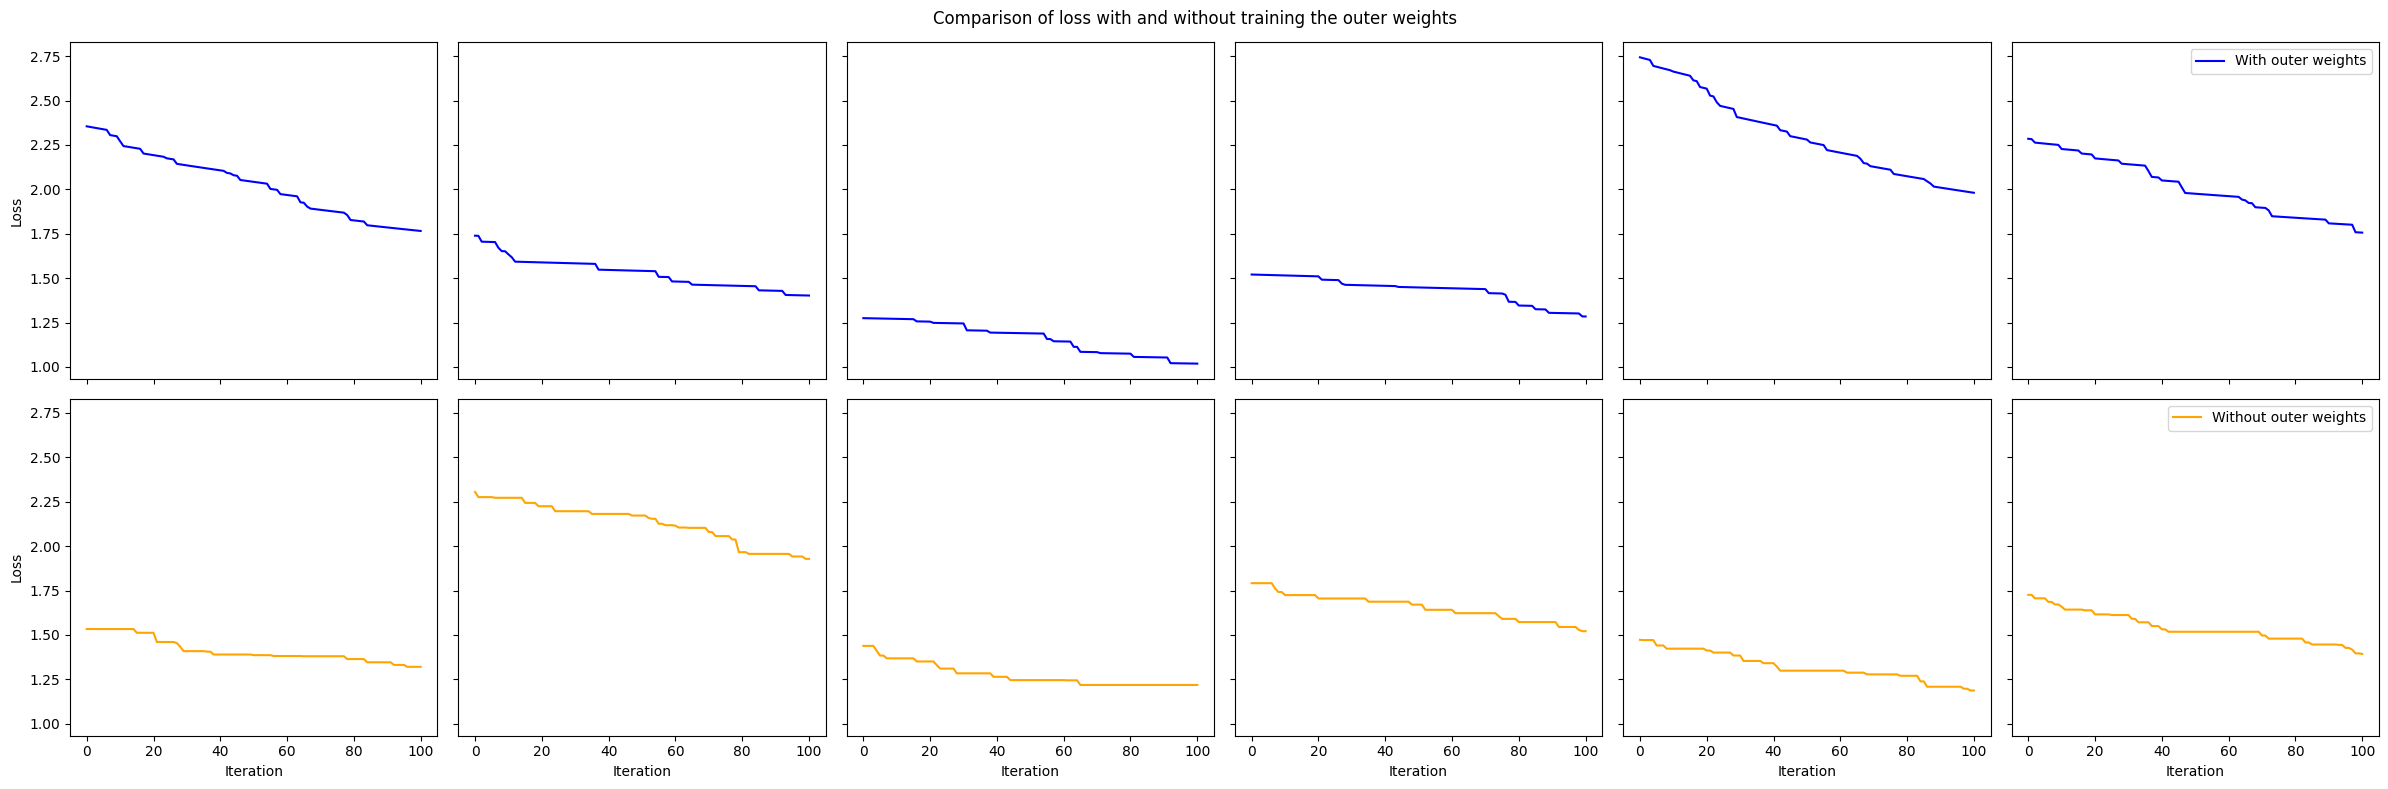

In [16]:
compare(n=10,d=6,m=100,b=0.1,t=0.001,num_iter=100,num_sim=6)

## Looking for an example where an inner weight goes to 0

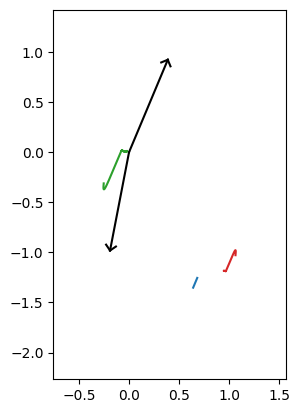

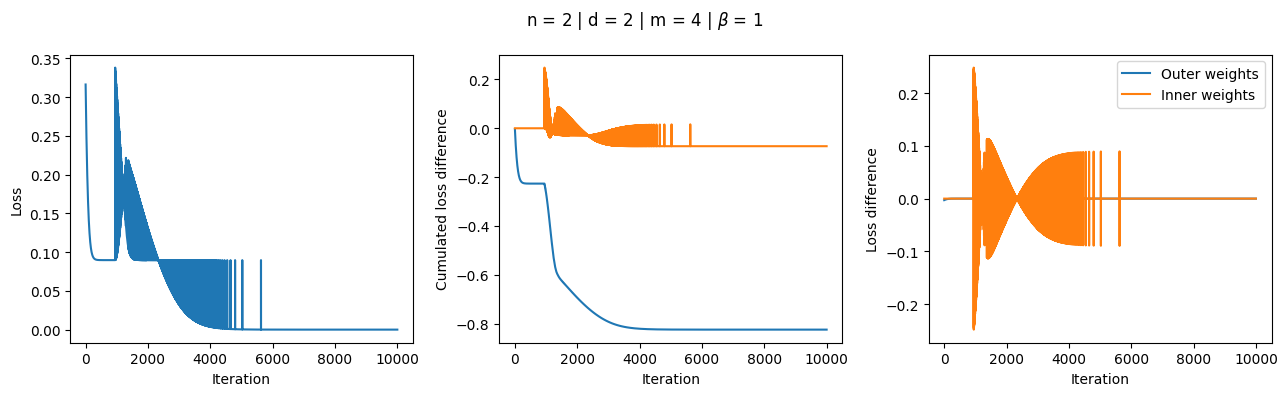

In [39]:
train_plot(n=2,d=2,m=4,b=1,t=0.01,num=10000,train_a=True)

# 3) Compare the dynamics of f_b and f_0

## Main function

In [9]:
def comp_fb_f0(n,d,m,betas,t,num,train_a = True):
    """
    INPUT: 1)n: number of input data for network
           2)d: dimension of input data
           3)m: number of neurons
           4)betas: list of values for beta
           5)t: time step for simulation
           6)num: number of steps for simulation
           7)train_a: indicates whether or not to train the outer weights
    OUTPUT: No output. Plots a grid, where each row shows the output of the neural network minus its initial output, for the true heaviside and surrogate heaviside, for one input value, over time.
    """

    #--------------Create data and weights--------------

    X,y = create_data(n,d)
    a,W = create_weights(m,d)

    #----------------------------

    #--------------Prepare plot grid and x axis values--------------

    fig, axs = plt.subplots(n,len(betas),figsize=(len(betas)*4,n*4),sharex=True,sharey=True)
    x_vals = [t*i for i in range(num+1)]

    #----------------------------

    #--------------Train and plot results--------------

    for i in range(len(betas)):             #iterate over the indices as these are needed for positioning in the grid
        b = betas[i]                        #extract current beta for simplicty
        NTK_inst = NTK_shallow(n=n,d=d,m=m,b=b,train_a=train_a,X=X,y=y,a=a,W=W)     #create network with correct beta, always with the same data and weights at initialisation
        NTK_inst.run_sim(t,num)             #run the simulation
        for j in range(n):                  #for each data point:
            y_vals = [x[j]-NTK_inst.f_iters[0][j] for x in NTK_inst.f_iters]        #f_0(t)-f_0(0) stored in an array
            y_vals_beta = [x[j]-NTK_inst.f_beta_iters[0][j]  for x in NTK_inst.f_beta_iters]    ##f_b(t)-f_b(0) stored in an array
            axs[j][i].plot(x_vals,y_vals,label="$f_0(t)-f_0(0)$")
            axs[j][i].plot(x_vals,y_vals_beta,label = "$f_\\beta(t)-f_\\beta(0)$")

    #----------------------------

    #--------------Title, axes labels,...--------------

    for j in range(n):                      #label y axes only on left side of grid
        axs[j][0].set_ylabel("$X_{num}$".replace("num",str(j)))
        
    for i in range(len(betas)):             
        axs[-1][i].set_xlabel("Time (t)")   #label x axes only on bottom of grid
        axs[0][i].set_title("$\\beta =$" + str(betas[i]))   #set title only on top of grid
    axs[0][-1].legend()                     #only one legend is needed as it is the same for each subplot
    fig.suptitle("n=" +str(n) + " | d=" + str(d) + " | m=" + str(m) + " | $\\Delta_t$=" + str(t))
    plt.show()

    #----------------------------

## Running some examples

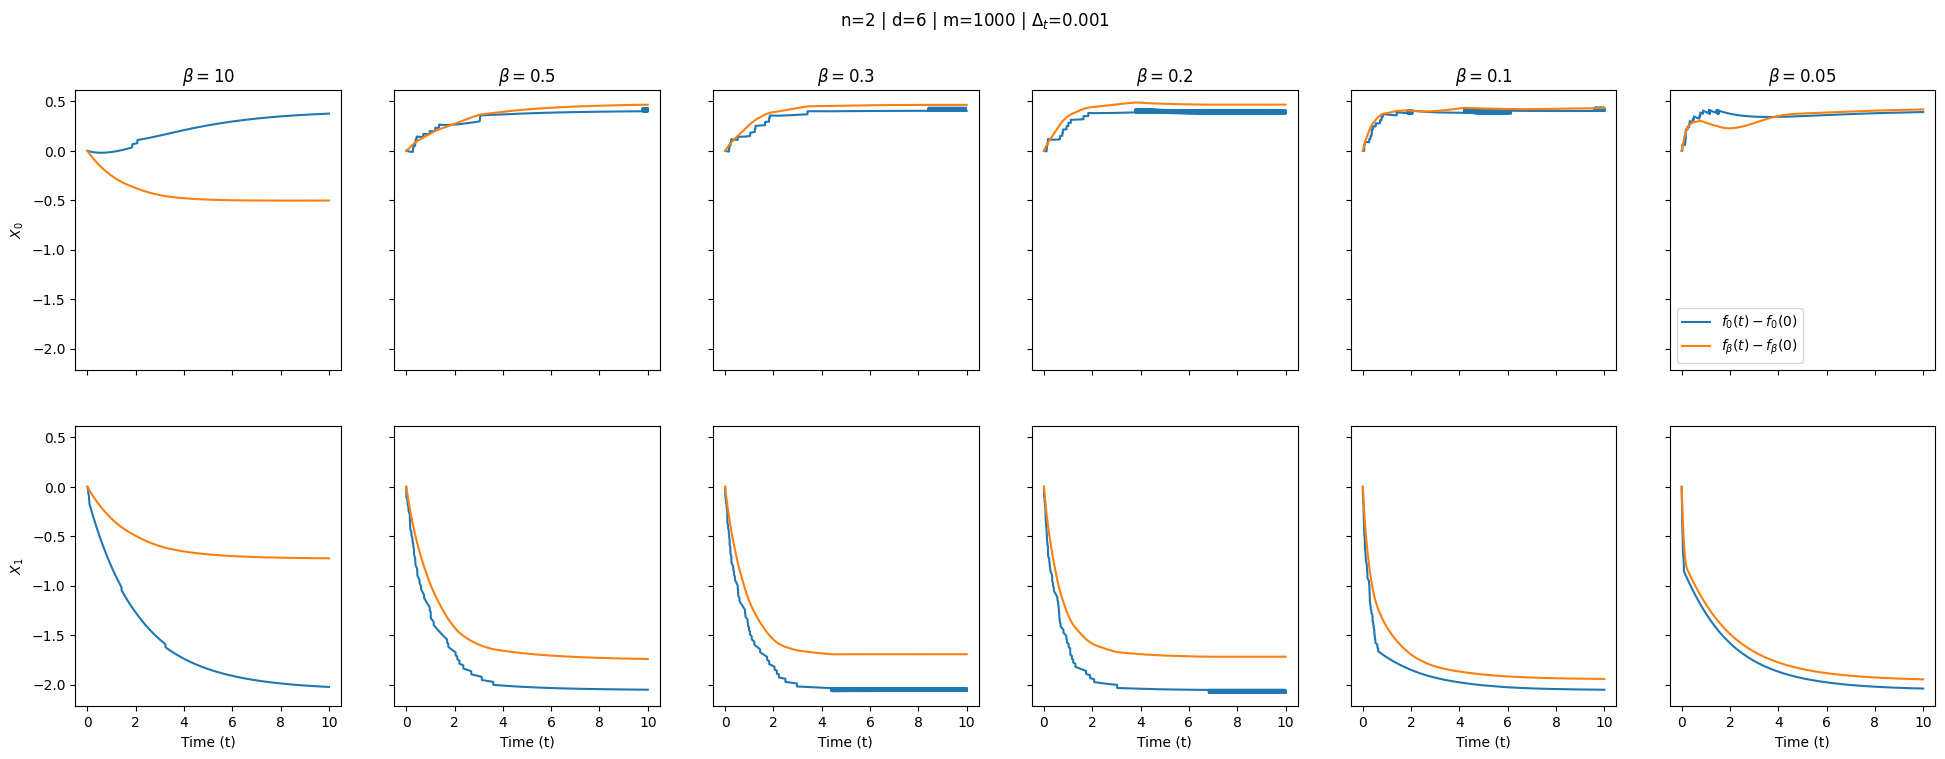

In [10]:
comp_fb_f0(n=2,d=6,m=1000,betas=[10,0.5,0.3,0.2,0.1,0.05],t=0.001,num=10000)

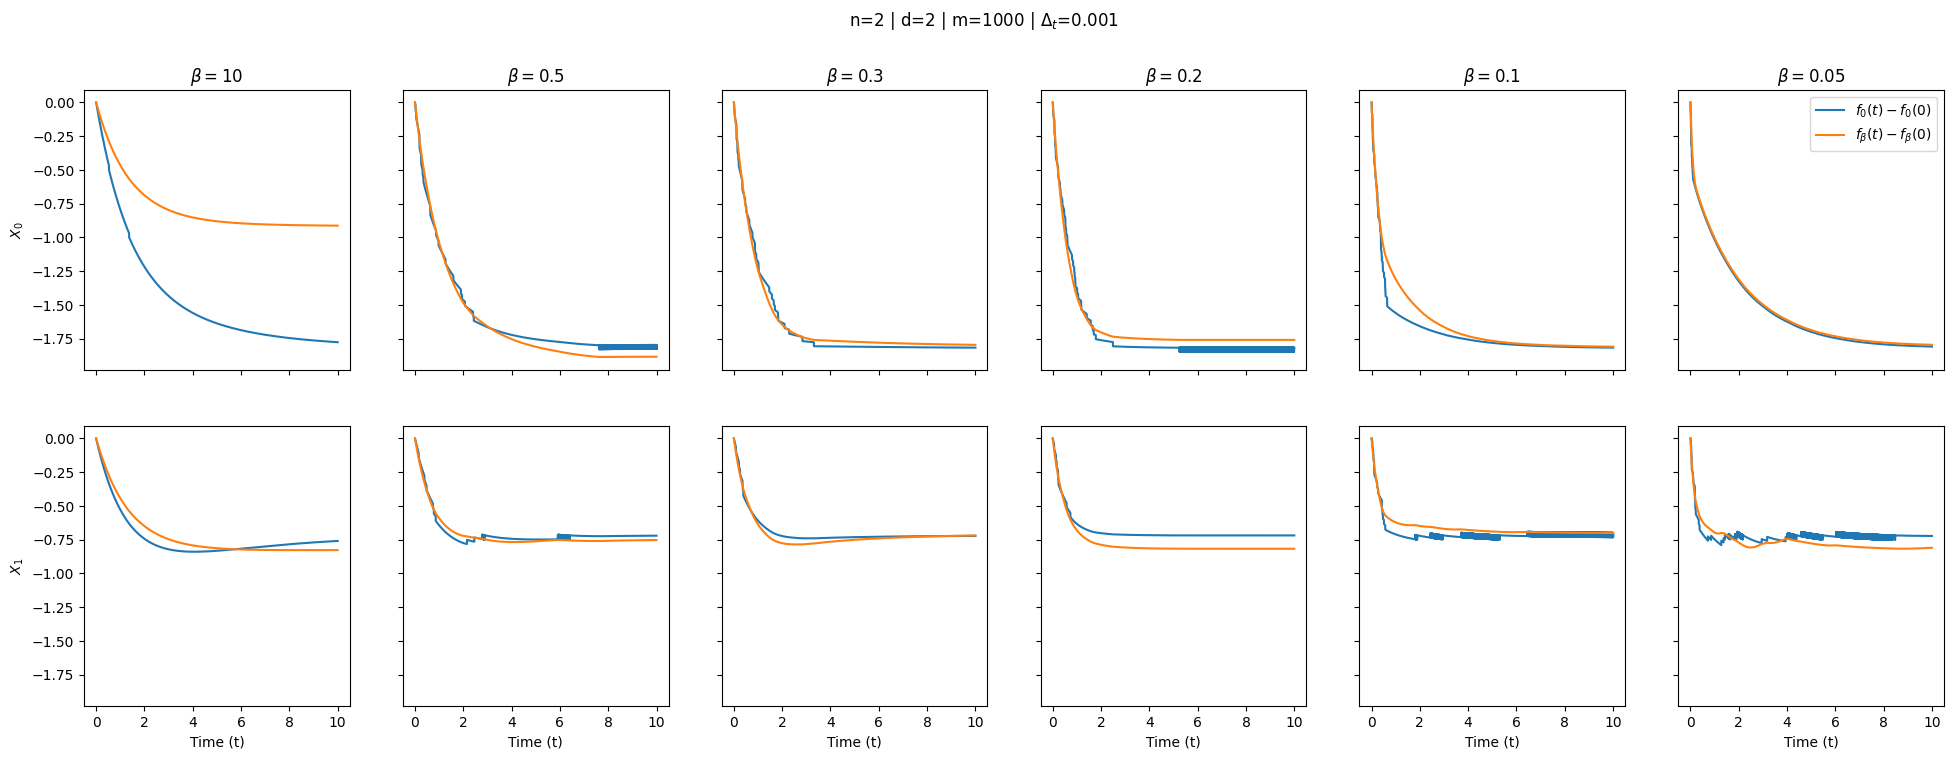

In [14]:
comp_fb_f0(n=2,d=2,m=1000,betas=[10,0.5,0.3,0.2,0.1,0.05],t=0.001,num=10000)

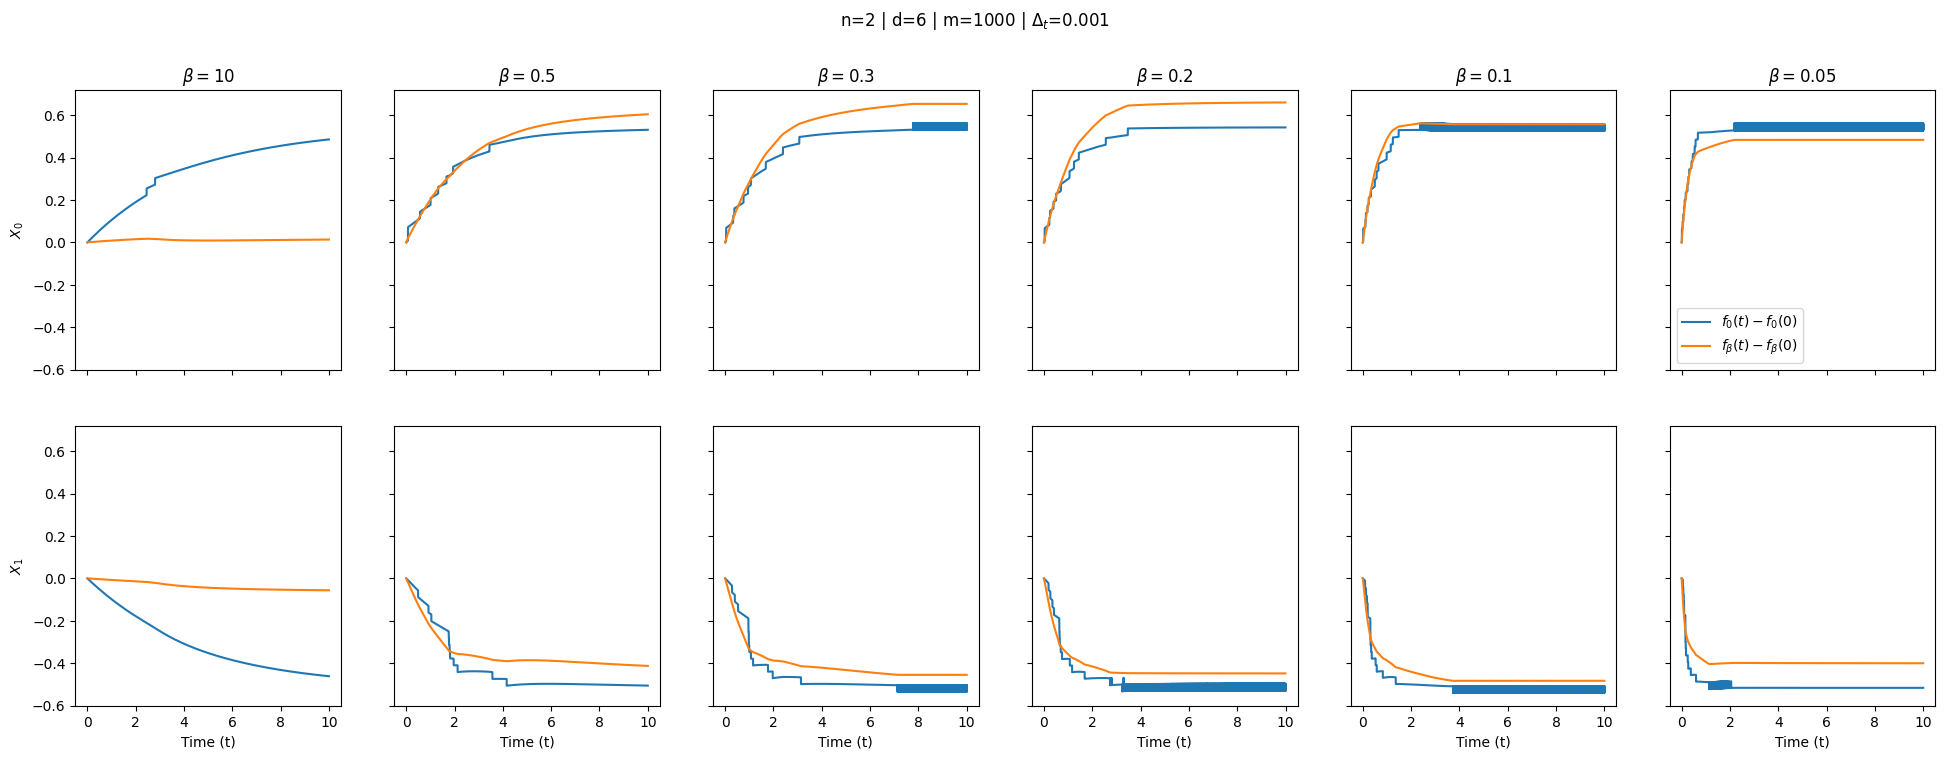

In [77]:
comp_fb_f0(n=2,d=6,m=1000,betas=[10,0.5,0.3,0.2,0.1,0.05],t=0.001,num=10000)

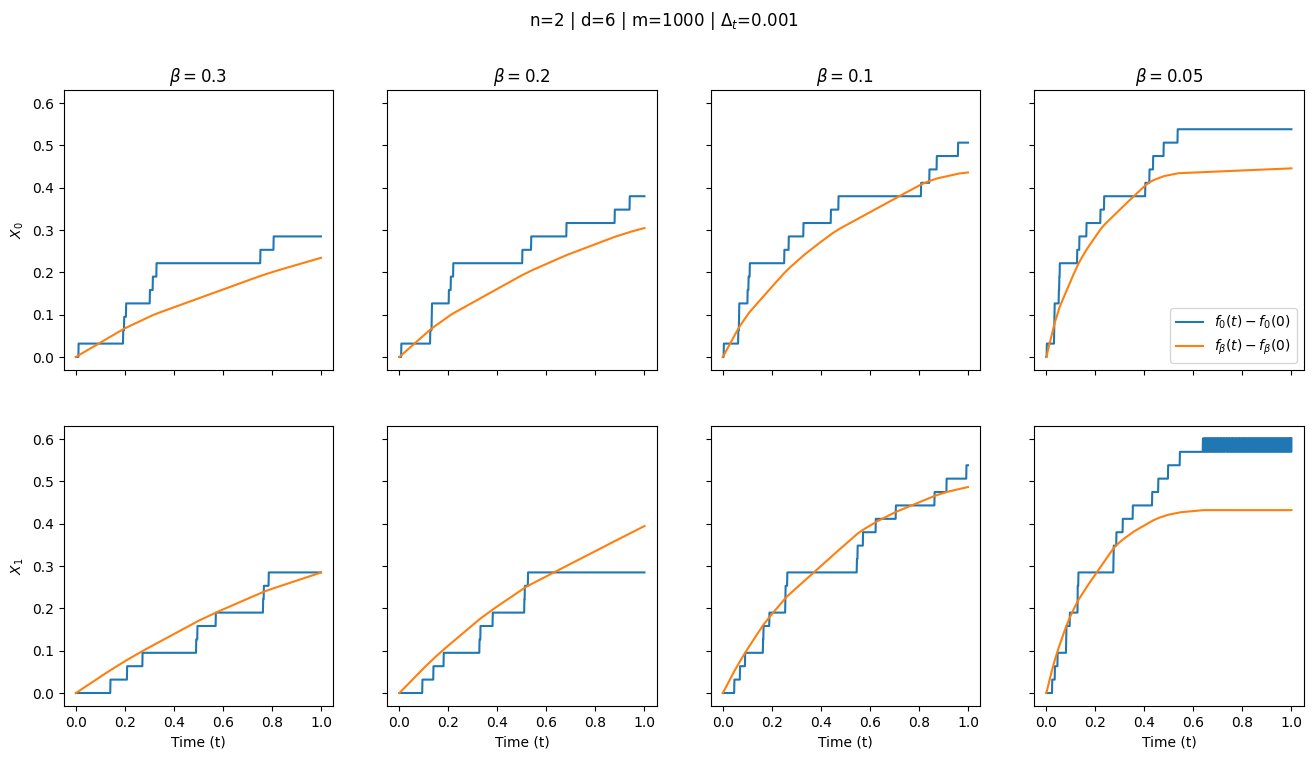

In [818]:
comp_fb_f0(n=2,d=6,m=1000,betas=[0.3,0.2,0.1,0.05],t=0.001,num=1000,train_a=False)

# 4) Look at how a*<w(t),x> behaves

## Main code

In [10]:
def show_awr(m,b,t,num,train_a = True,arrow_size = 0.02, want_flat_end = False):

    #--------------Weight and data intialisation--------------

    n = 1
    d = 2
    m = min(m,20)           #our colour scale only has 20 colours
    X,y = create_data(n,d)  #create data
    a = []                  #empty arrays to iteratively fill up
    W = []
    for k in range(m):      #want k weights
        stop = False
        while not stop:     #sample randomly until neuron will be active, otherwhise not very interesting for the plot
            w1 = np.random.normal(size=(1,d))[0]
            for i in range(n):
                if abs(np.dot(w1,X[i])) < b:    #check if neuron will be active
                    stop = True                 #if neuron active we found one more weight
        a1 = 1#np.random.choice(np.array([int(-1),int(1)]),size = 1)[0]
        a.append(a1)        #add chosen weights
        W.append(w1)
    y_0 = NTK_output(a,W,X)
    temp = random.randrange(1,5)
    y = [y_0[i]-temp for i in range(n)]     #want the delta at time 0 to be positive

    #----------------------------

    #--------------Initialise and train network--------------

    NTK_inst = NTK_shallow(n=n,d=d,m=m,b=b,train_a=train_a,X=X,y=y,a=a,W=W)
    NTK_inst.run_sim(t,num)

    #----------------------------

    #--------------Check where the x axis is intersected--------------

    x_cut_times = []
    possible_r = [r for r in range(m)]          #note for which indices an intersection already occured
    for i in range(len(NTK_inst.awx_iter)-1):
        for r in range(NTK_inst.m):
            if r in possible_r:                 #sometimes they jump around the x axis, avoid counting these crossings
                if np.sign(NTK_inst.awx_iter[i][r]) != np.sign(NTK_inst.awx_iter[i+1][r]):      #check if the x axis was crossed
                    x_cut_times.append((i,r))   #if so store weight index and time
                    possible_r.remove(r)        #keep track of the fact that this index already had a crossing
    
    if want_flat_end:   #I wanted a plot where they flatten out, so I checked whether the last one "jumped" around the x axis, indicating it flattend out
        all_x_cut_times = [(i,r) for i in range(len(NTK_inst.awx_iter)-1) for r in range(NTK_inst.m) if np.sign(NTK_inst.awx_iter[i][r]) != np.sign(NTK_inst.awx_iter[i+1][r])]
        if (len(all_x_cut_times) == len(x_cut_times)):
            return(0)   #return a 0 so I may build a loop to keep trying, 0 = failed, 1 = succeeded
        
    #----------------------------

    #--------------Plotting--------------
    
    #-------Plot a_r <w_r,x> over time-------

    fig, axs = plt.subplots(1,1,figsize=(16,9))  
    cmap = plt.cm.tab20                         #choose colour palette
    for r in range(NTK_inst.m):                 #plot a_r <w_r,x> for each r
        y_vals = [x[r] for x in NTK_inst.awx_iter]
        axs.plot([i*t for i in range(len(y_vals))],y_vals,color = cmap(r),zorder=1)     #want to ensure the following elements are plotted over it

    #--------------

    #-------Show where intersections with x axis occur-------

    for j,r in x_cut_times:                     #j = time, r = index for cut
        axs.plot([j*t,j*t],[-b,b],linestyle="dashed",color = cmap(r),zorder=2)  #plot vertical line, it will intersect with all the created "elbows"
        axs.scatter([j*t],[0],color = "black",marker='x',s=100,zorder=3)        #plot x marker where crossover happend

    #--------------

    #-------Visually show rho_k-------

    y_last = max([NTK_inst.awx_iter[0][r] for r in range(m) if NTK_inst.awx_iter[0][r] < b])    #compute x and y coordinates of last crossover
    x_last = x_cut_times[-1][0]*t

    axs.plot([0,x_last+((num*t)/20)],[y_last,y_last],color="grey",linestyle="dotted")           #plot vertical dashed lines
    axs.plot([x_last,x_last+((num*t)/20)],[0,0],color="grey",linestyle="dotted")

    plt.plot([x_last+((num*t)/20),x_last+((num*t)/20)],[0,y_last],color = "black")              #plot segment with arrows on both ends indicating rho_k
    plt.plot([x_last-arrow_size*((num*t)/(2*b))*y_last+((num*t)/20),x_last+((num*t)/20)],[(1-arrow_size)*y_last,y_last],color = "black")
    plt.plot([x_last+arrow_size*((num*t)/(2*b))*y_last+((num*t)/20),x_last+((num*t)/20)],[(1-arrow_size)*y_last,y_last],color = "black")
    plt.plot([x_last-arrow_size*((num*t)/(2*b))*y_last+((num*t)/20),x_last+((num*t)/20)],[(arrow_size)*y_last,0],color = "black")
    plt.plot([x_last+arrow_size*((num*t)/(2*b))*y_last+((num*t)/20),x_last+((num*t)/20)],[(arrow_size)*y_last,0],color = "black")

    plt.text(x_last+((num*t)/20), y_last/2, "$B({num},$".replace("num",str(len(x_cut_times)))+"${num})$".replace("num",str(m)), fontsize=12)
                                                                                                #add text with rho_k to graphic    
    #--------------

    #-------Cleaning up the plot-------

    axs.set_ylim(-b, b)                 #Set y-axis so the plot show the whole range where neurons would be active
    axs.set_ylabel("$a_r(t) \mathbf{w}_r^\\top(t) \mathbf{x}$")     #show what we plot on the y axis
        
    axs.set_xlabel("Time (t)")          #label x axes only on bottom of grid
    axs.set_title("n=" +str(n) + " | d=" + str(d) + " | m=" + str(m) + " | $\\Delta_t$=" + str(t) + " | $\\beta =$" + str(b))   #set title 
    
    xticks = np.append([0,num*t],[j*t for j,r in x_cut_times])      #only show extremities of time and crossover times
    xlabels = np.append([0,math.ceil(num*t)],["$T_{num}$".replace("num",str(i+1)) for i in range(len(xticks)-2)])   #corresponding labels
    axs.set_xticks(xticks, labels=xlabels)                          #set the desired ticks
    
    plt.tight_layout()
    plt.show()

    if want_flat_end:                   #so I know I got a graph with a flat end (*・‿・)ノ⌒*:･ﾟ✧
        return(1)
    
    #----------------------------


<>:93: SyntaxWarning: invalid escape sequence '\m'
<>:93: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1723/3254866408.py:93: SyntaxWarning: invalid escape sequence '\m'
  axs.set_ylabel("$a_r(t) \mathbf{w}_r^\\top(t) \mathbf{x}$")     #show what we plot on the y axis


## Running some simulations

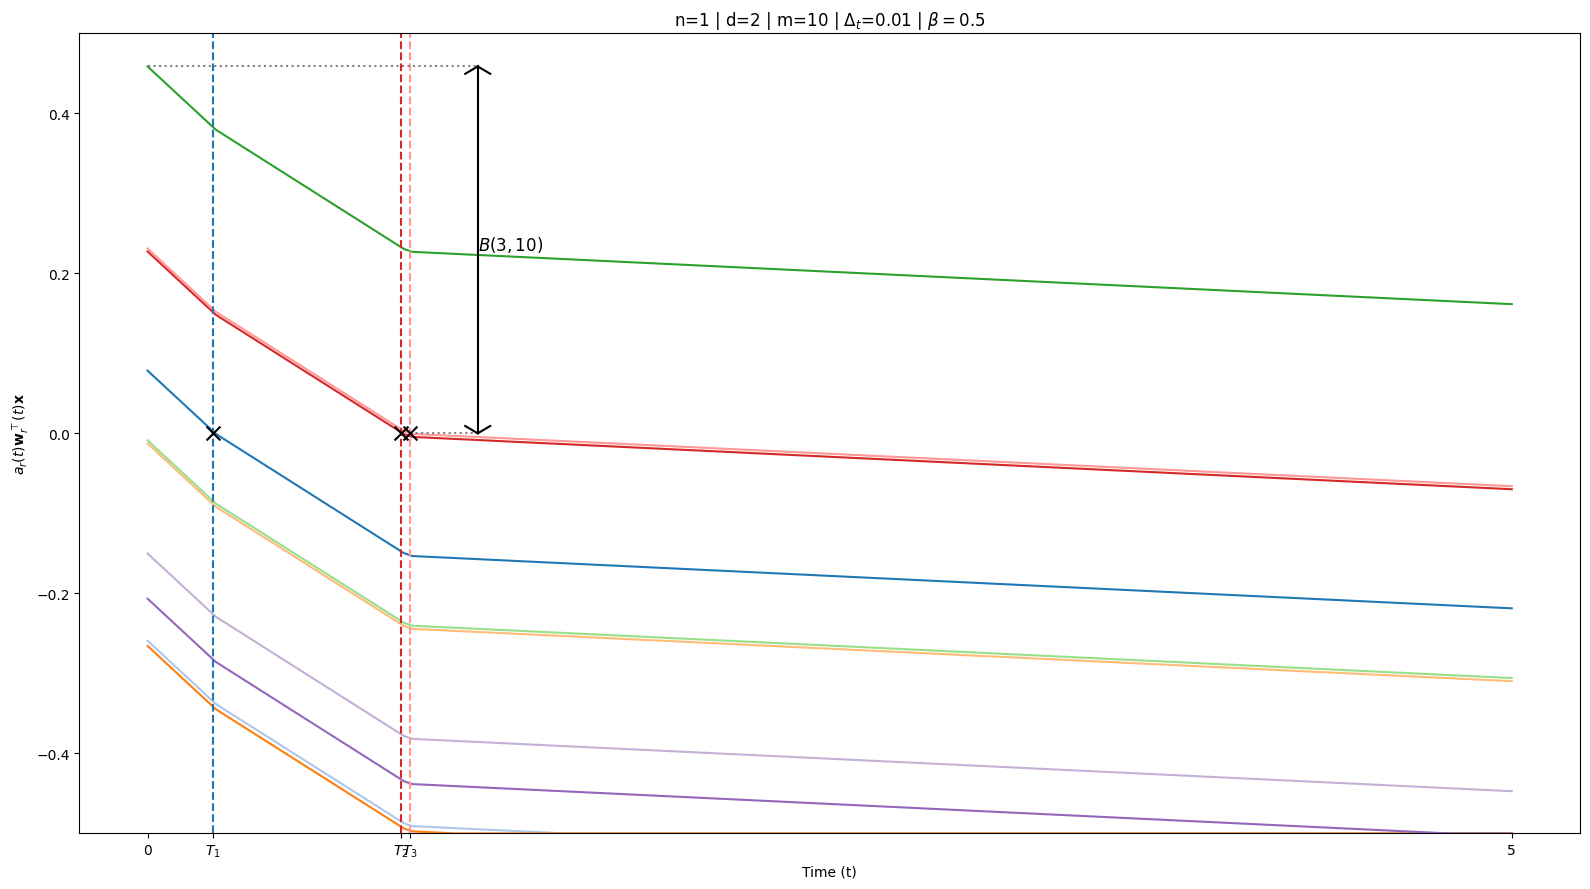

In [15]:
show_awr(m=10,b=0.5,t=0.01,num=500,train_a = False)

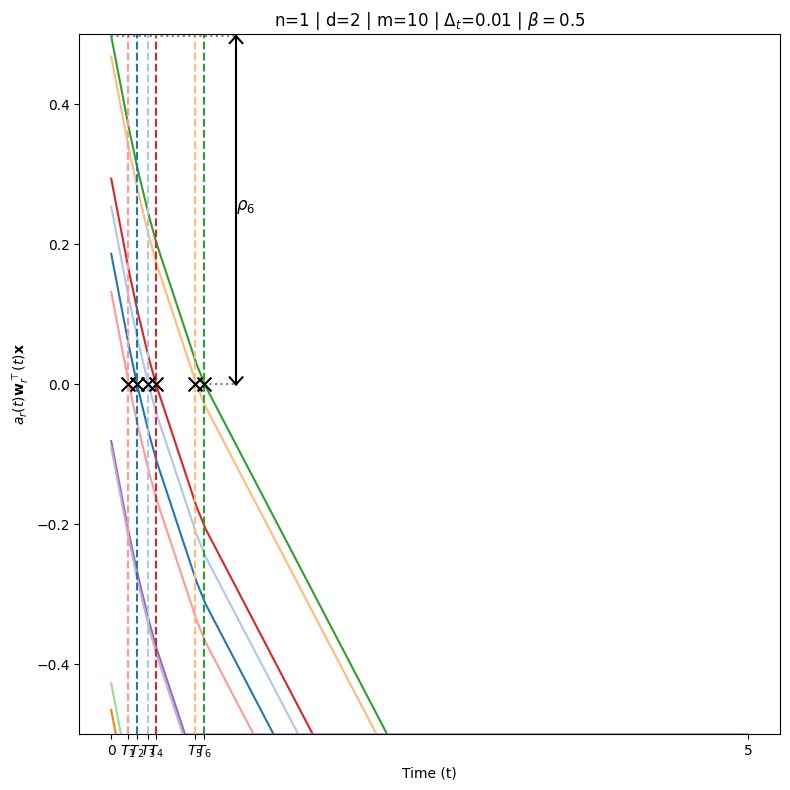

In [21]:
show_awr(m=10,b=0.5,t=0.01,num=500,train_a = False)

## Looking for a plot that flattens out at the end

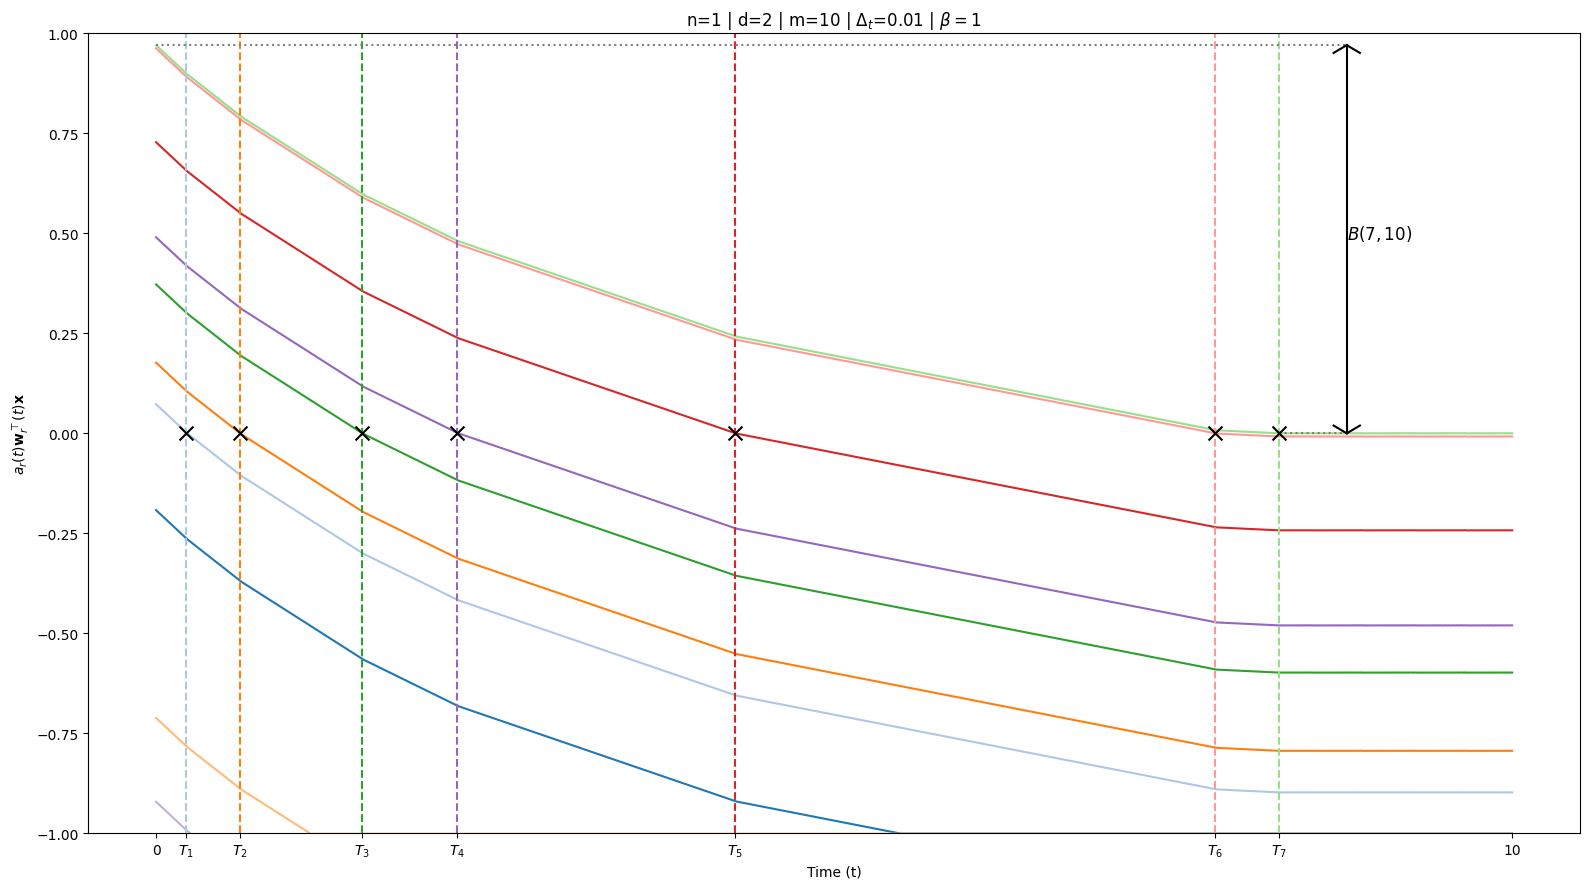

In [21]:
while True:
    if show_awr(m=10,b=1,t=0.01,num=1000,train_a = False,want_flat_end=True) == 1:
        break


# Check error at initialisation as function of beta

In [69]:
def init_error(d,ms,betas,num_calc):
    cmap = plt.cm.tab20
    fig, ax = plt.subplots(1, len(ms),sharey=True,figsize=(3*len(ms),4))
    j = 0
    for m in ms:
        errors = []
        for b in betas:
            val = 0
            for i in range(num_calc):
                X,y = create_data(1,d)
                a,W = create_weights(m,d)
                val += abs(NTK_output_beta(a,W,X,b)[0] - NTK_output(a,W,X)[0])
            errors += [val/num_calc]
        max_error = max(errors)
        sqrts = [math.sqrt(b) for b in betas]
        max_sqrts = max(sqrts)
        sqrts = [(s*max_error)/max_sqrts for s in sqrts]
        ax[j].plot(betas,errors,color = cmap(0))
        ax[j].plot(betas,sqrts,color = cmap(3))
        ax[j].set_title("m = " + str(m))
        ax[j].set_xlabel("$\\beta$")
        j += 1
        
        #"$|f_{\\beta} (\mathbf{a}, \mathbf{W},\mathbf{x}) - f (\mathbf{a}, \mathbf{W},\mathbf{x})|$"
    fig.legend(["$|f_{\\beta} (\mathbf{a}, \mathbf{W},\mathbf{x}) - f (\mathbf{a}, \mathbf{W},\mathbf{x})|$","\\sim \sqrt{\\beta}"])


<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1723/3177628123.py:25: SyntaxWarning: invalid escape sequence '\m'
  fig.legend(["$|f_{\\beta} (\mathbf{a}, \mathbf{W},\mathbf{x}) - f (\mathbf{a}, \mathbf{W},\mathbf{x})|$","\\sim \sqrt{\\beta}"])
/tmp/ipykernel_1723/3177628123.py:25: SyntaxWarning: invalid escape sequence '\s'
  fig.legend(["$|f_{\\beta} (\mathbf{a}, \mathbf{W},\mathbf{x}) - f (\mathbf{a}, \mathbf{W},\mathbf{x})|$","\\sim \sqrt{\\beta}"])


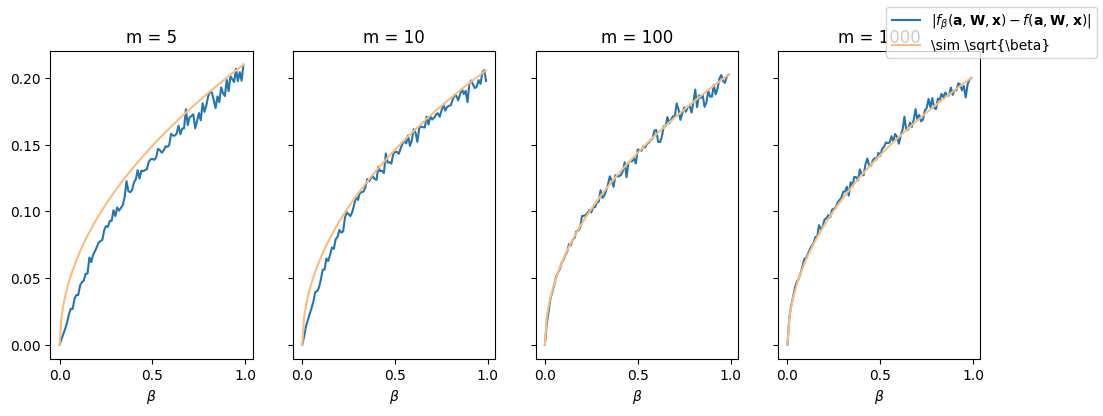

In [72]:
init_error(3,[5,10,100,1000],[i/100 for i in range(100)],1000)